In [ ]:
from google.colab import files
uploaded=files.upload()
print(uploaded)

Saving proj1.csv to proj1.csv
{'proj1.csv': b'06.15 6:34 AM\nStudent_ID,Name,Age,Gender,Department,Study_Hours_Per_Day,Attendance_Percentage,Assignments_Completed,Midterm_Score,Final_Score,Projects_Score,Extra_Curricular,Internet_Access,Family_Income,Parent_Education,Sleep_Hours,Stress_Level,Final_Grade\nS001,Alice Johnson,20,Female,Computer Science,6,92,18,78,82,88,Yes,Yes,High,Graduate,7,Low,A\nS002,Bob Smith,21,Male,Mathematics,4,85,15,65,70,72,No,Yes,Medium,Undergraduate,6,Medium,B\nS003,Carol White,19,Female,Physics,7,95,20,88,91,90,Yes,Yes,High,Graduate,8,Low,A\nS004,David Brown,22,Male,Chemistry,3,70,12,55,58,60,No,No,Low,High School,5,High,C\nS005,Emma Davis,20,Female,Computer Science,5,88,17,75,79,80,Yes,Yes,Medium,Graduate,7,Low,B\nS006,Frank Miller,23,Male,Mathematics,2,65,10,45,50,48,No,No,Low,High School,4,High,D\nS007,Grace Wilson,21,Female,Physics,6,90,19,82,85,87,Yes,Yes,High,Graduate,7,Low,A\nS008,Henry Moore,20,Male,Chemistry,4,80,14,68,72,70,No,Yes,Medium,Undergradua

In [ ]:
# ============================================================
# PROJECT 5: REPORTING AND INSIGHT GENERATION
# ============================================================
# Description: Transform analysis results into actionable
#              business insights and professional reports
# ============================================================

# --- LIBRARY IMPORTS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# --- GLOBAL STYLE CONFIGURATION ---
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor': '#FFFFFF',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.color': '#CCCCCC',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Color palette
COLORS = {
    'primary':    '#2E86AB',
    'secondary':  '#A23B72',
    'success':    '#2ECC71',
    'warning':    '#F39C12',
    'danger':     '#E74C3C',
    'neutral':    '#95A5A6',
    'dark':       '#2C3E50',
    'light':      '#ECF0F1',
    'palette':    ['#2E86AB','#A23B72','#2ECC71',
                   '#F39C12','#E74C3C','#9B59B6',
                   '#1ABC9C','#E67E22']
}

print("✅ Libraries loaded and styles configured.")
print("=" * 55)

✅ Libraries loaded and styles configured.


In [ ]:
# ============================================================
# SECTION 1: SYNTHETIC BUSINESS DATA GENERATION
# ============================================================
# Realistic data simulating 2 years of business operations
# across multiple regions, product categories, and channels
# ============================================================

np.random.seed(42)

# --- TIME RANGE ---
date_range = pd.date_range(start='2022-01-01', end='2023-12-31', freq='D')
n = 1200  # number of transactions

# --- CATEGORICAL VARIABLES ---
regions      = ['North', 'South', 'East', 'West', 'Central']
categories   = ['Electronics', 'Clothing', 'Food & Beverage',
                'Home & Garden', 'Sports', 'Beauty']
channels     = ['Online', 'In-Store', 'Mobile App', 'Wholesale']
segments     = ['Premium', 'Standard', 'Budget']
sales_reps   = [f'Rep_{i:02d}' for i in range(1, 16)]

# --- REGION WEIGHTS (simulate unequal market sizes) ---
region_weights = [0.25, 0.20, 0.22, 0.18, 0.15]

# --- GENERATE BASE DATAFRAME ---
df = pd.DataFrame({
    'date': np.random.choice(date_range, n),
    'region': np.random.choice(regions, n, p=region_weights),
    'category': np.random.choice(categories, n),
    'channel': np.random.choice(
        channels, n, p=[0.35, 0.30, 0.25, 0.10]
    ),
    'segment': np.random.choice(
        segments, n, p=[0.25, 0.50, 0.25]
    ),
    'sales_rep': np.random.choice(sales_reps, n),
    'units_sold': np.random.randint(1, 150, n),
    'customer_id': np.random.randint(1000, 5000, n),
})

# --- PRICE MODEL (category-based with noise) ---
base_prices = {
    'Electronics':     450,
    'Clothing':         85,
    'Food & Beverage':  32,
    'Home & Garden':   120,
    'Sports':           95,
    'Beauty':           65,
}

# --- SEGMENT MULTIPLIERS ---
seg_multipliers = {'Premium': 1.40, 'Standard': 1.00, 'Budget': 0.70}

df['unit_price'] = df.apply(
    lambda r: max(
        5,
        base_prices[r['category']]
        * seg_multipliers[r['segment']]
        * np.random.uniform(0.85, 1.15)
    ), axis=1
).round(2)

# --- REVENUE & COST CALCULATIONS ---
df['revenue']      = (df['units_sold'] * df['unit_price']).round(2)
df['cost']         = (df['revenue'] * np.random.uniform(0.55, 0.72, n)).round(2)
df['gross_profit'] = (df['revenue'] - df['cost']).round(2)
df['profit_margin']= ((df['gross_profit'] / df['revenue']) * 100).round(2)

# --- DISCOUNT APPLIED ---
df['discount_pct'] = np.random.choice(
    [0, 5, 10, 15, 20, 25],
    n,
    p=[0.40, 0.20, 0.18, 0.12, 0.07, 0.03]
)
df['discount_amt'] = (df['revenue'] * df['discount_pct'] / 100).round(2)
df['net_revenue']  = (df['revenue'] - df['discount_amt']).round(2)

# --- CUSTOMER SATISFACTION SCORE (1-5) ---
df['satisfaction'] = np.clip(
    np.random.normal(3.8, 0.7, n), 1, 5
).round(1)

# --- RETURN FLAG (higher for low satisfaction) ---
df['returned'] = (
    (df['satisfaction'] < 2.5) |
    (np.random.random(n) < 0.04)
).astype(int)

# --- DATE FEATURES ---
df['date']    = pd.to_datetime(df['date'])
df['year']    = df['date'].dt.year
df['month']   = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter
df['month_name'] = df['date'].dt.strftime('%b')
df['day_of_week'] = df['date'].dt.day_name()
df['week']    = df['date'].dt.isocalendar().week.astype(int)

# --- SORT ---
df = df.sort_values('date').reset_index(drop=True)

print(f"✅ Dataset Generated Successfully")
print(f"   Shape       : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Date Range  : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"   Total Revenue: ${df['revenue'].sum():>12,.2f}")
print(f"   Total Profit : ${df['gross_profit'].sum():>12,.2f}")
print(f"   Avg Margin   : {df['profit_margin'].mean():.1f}%")
print(f"   Return Rate  : {df['returned'].mean()*100:.1f}%")
print("\n📋 Sample Records:")
print(df[['date','region','category','channel',
          'units_sold','revenue','profit_margin',
          'satisfaction']].head(6).to_string(index=False))

✅ Dataset Generated Successfully
   Shape       : 1,200 rows × 24 columns
   Date Range  : 2022-01-01 → 2023-12-31
   Total Revenue: $13,442,780.20
   Total Profit : $4,934,503.78
   Avg Margin   : 36.6%
   Return Rate  : 5.9%

📋 Sample Records:
      date region        category    channel  units_sold  revenue  profit_margin  satisfaction
2022-01-01   East        Clothing Mobile App         107  8025.00          33.27           5.0
2022-01-01  North   Home & Garden     Online         115 15779.15          35.62           3.0
2022-01-01  South   Home & Garden   In-Store          34  3928.70          40.16           5.0
2022-01-01   West     Electronics     Online          57 26295.24          35.24           2.9
2022-01-02  South Food & Beverage     Online          80  2892.80          42.90           3.6
2022-01-02  North Food & Beverage     Online          43  1390.19          35.37           3.4


In [ ]:
# ============================================================
# SECTION 2: EXECUTIVE KPI SUMMARY DASHBOARD
# ============================================================
# High-level metrics for C-suite decision making
# ============================================================

def compute_kpis(data, year=None):
    """Compute key performance indicators for a given year."""
    d = data[data['year'] == year] if year else data
    return {
        'total_revenue':    d['revenue'].sum(),
        'net_revenue':      d['net_revenue'].sum(),
        'total_profit':     d['gross_profit'].sum(),
        'avg_margin':       d['profit_margin'].mean(),
        'total_units':      d['units_sold'].sum(),
        'transactions':     len(d),
        'avg_order_value':  d['revenue'].mean(),
        'unique_customers': d['customer_id'].nunique(),
        'return_rate':      d['returned'].mean() * 100,
        'avg_satisfaction': d['satisfaction'].mean(),
        'top_category':     d.groupby('category')['revenue'].sum().idxmax(),
        'top_region':       d.groupby('region')['revenue'].sum().idxmax(),
    }

kpi_2022 = compute_kpis(df, 2022)
kpi_2023 = compute_kpis(df, 2023)
kpi_all  = compute_kpis(df)

# --- YoY GROWTH CALCULATIONS ---
def yoy(new, old):
    return ((new - old) / old) * 100 if old != 0 else 0

growth = {
    'revenue':       yoy(kpi_2023['total_revenue'],    kpi_2022['total_revenue']),
    'profit':        yoy(kpi_2023['total_profit'],     kpi_2022['total_profit']),
    'margin':        kpi_2023['avg_margin'] - kpi_2022['avg_margin'],
    'units':         yoy(kpi_2023['total_units'],      kpi_2022['total_units']),
    'aov':           yoy(kpi_2023['avg_order_value'],  kpi_2022['avg_order_value']),
    'satisfaction':  kpi_2023['avg_satisfaction'] - kpi_2022['avg_satisfaction'],
}

# ── PRINT EXECUTIVE SUMMARY ──────────────────────────────────
print("=" * 65)
print("        EXECUTIVE PERFORMANCE SUMMARY REPORT")
print("        Fiscal Years 2022 – 2023  |  All Regions")
print("=" * 65)

kpi_rows = [
    ("Total Revenue",      kpi_2022['total_revenue'],
                           kpi_2023['total_revenue'],   "${:,.0f}", growth['revenue']),
    ("Net Revenue",        kpi_2022['net_revenue'],
                           kpi_2023['net_revenue'],     "${:,.0f}", None),
    ("Gross Profit",       kpi_2022['total_profit'],
                           kpi_2023['total_profit'],    "${:,.0f}", growth['profit']),
    ("Avg Profit Margin",  kpi_2022['avg_margin'],
                           kpi_2023['avg_margin'],      "{:.1f}%",  growth['margin']),
    ("Units Sold",         kpi_2022['total_units'],
                           kpi_2023['total_units'],     "{:,.0f}",  growth['units']),
    ("Transactions",       kpi_2022['transactions'],
                           kpi_2023['transactions'],    "{:,.0f}",  None),
    ("Avg Order Value",    kpi_2022['avg_order_value'],
                           kpi_2023['avg_order_value'], "${:,.2f}", growth['aov']),
    ("Unique Customers",   kpi_2022['unique_customers'],
                           kpi_2023['unique_customers'],"{:,.0f}",  None),
    ("Return Rate",        kpi_2022['return_rate'],
                           kpi_2023['return_rate'],     "{:.1f}%",  None),
    ("Avg Satisfaction",   kpi_2022['avg_satisfaction'],
                           kpi_2023['avg_satisfaction'],"{:.2f}/5", growth['satisfaction']),
]

print(f"\n{'Metric':<22} {'2022':>14} {'2023':>14} {'YoY Δ':>10}")
print("-" * 65)
for name, v22, v23, fmt, g in kpi_rows:
    s22 = fmt.format(v22)
    s23 = fmt.format(v23)
    if g is not None:
        arrow = "▲" if g > 0 else "▼"
        g_str = f"{arrow} {abs(g):+.1f}%"
    else:
        g_str = "—"
    print(f"  {name:<20} {s22:>14} {s23:>14} {g_str:>10}")

print("-" * 65)
print(f"\n  🏆 Top Category  : {kpi_2023['top_category']}")
print(f"  🌍 Top Region    : {kpi_2023['top_region']}")
print("=" * 65)

        EXECUTIVE PERFORMANCE SUMMARY REPORT
        Fiscal Years 2022 – 2023  |  All Regions

Metric                           2022           2023      YoY Δ
-----------------------------------------------------------------
  Total Revenue            $6,899,580     $6,543,200    ▼ +5.2%
  Net Revenue              $6,427,134     $6,071,341          —
  Gross Profit             $2,556,153     $2,378,351    ▼ +7.0%
  Avg Profit Margin             36.7%          36.5%    ▼ +0.3%
  Units Sold                   45,898         46,774    ▲ +1.9%
  Transactions                    607            593          —
  Avg Order Value          $11,366.69     $11,034.06    ▼ +2.9%
  Unique Customers                563            551          —
  Return Rate                    5.1%           6.7%          —
  Avg Satisfaction             3.79/5         3.78/5    ▼ +0.0%
-----------------------------------------------------------------

  🏆 Top Category  : Electronics
  🌍 Top Region    : North


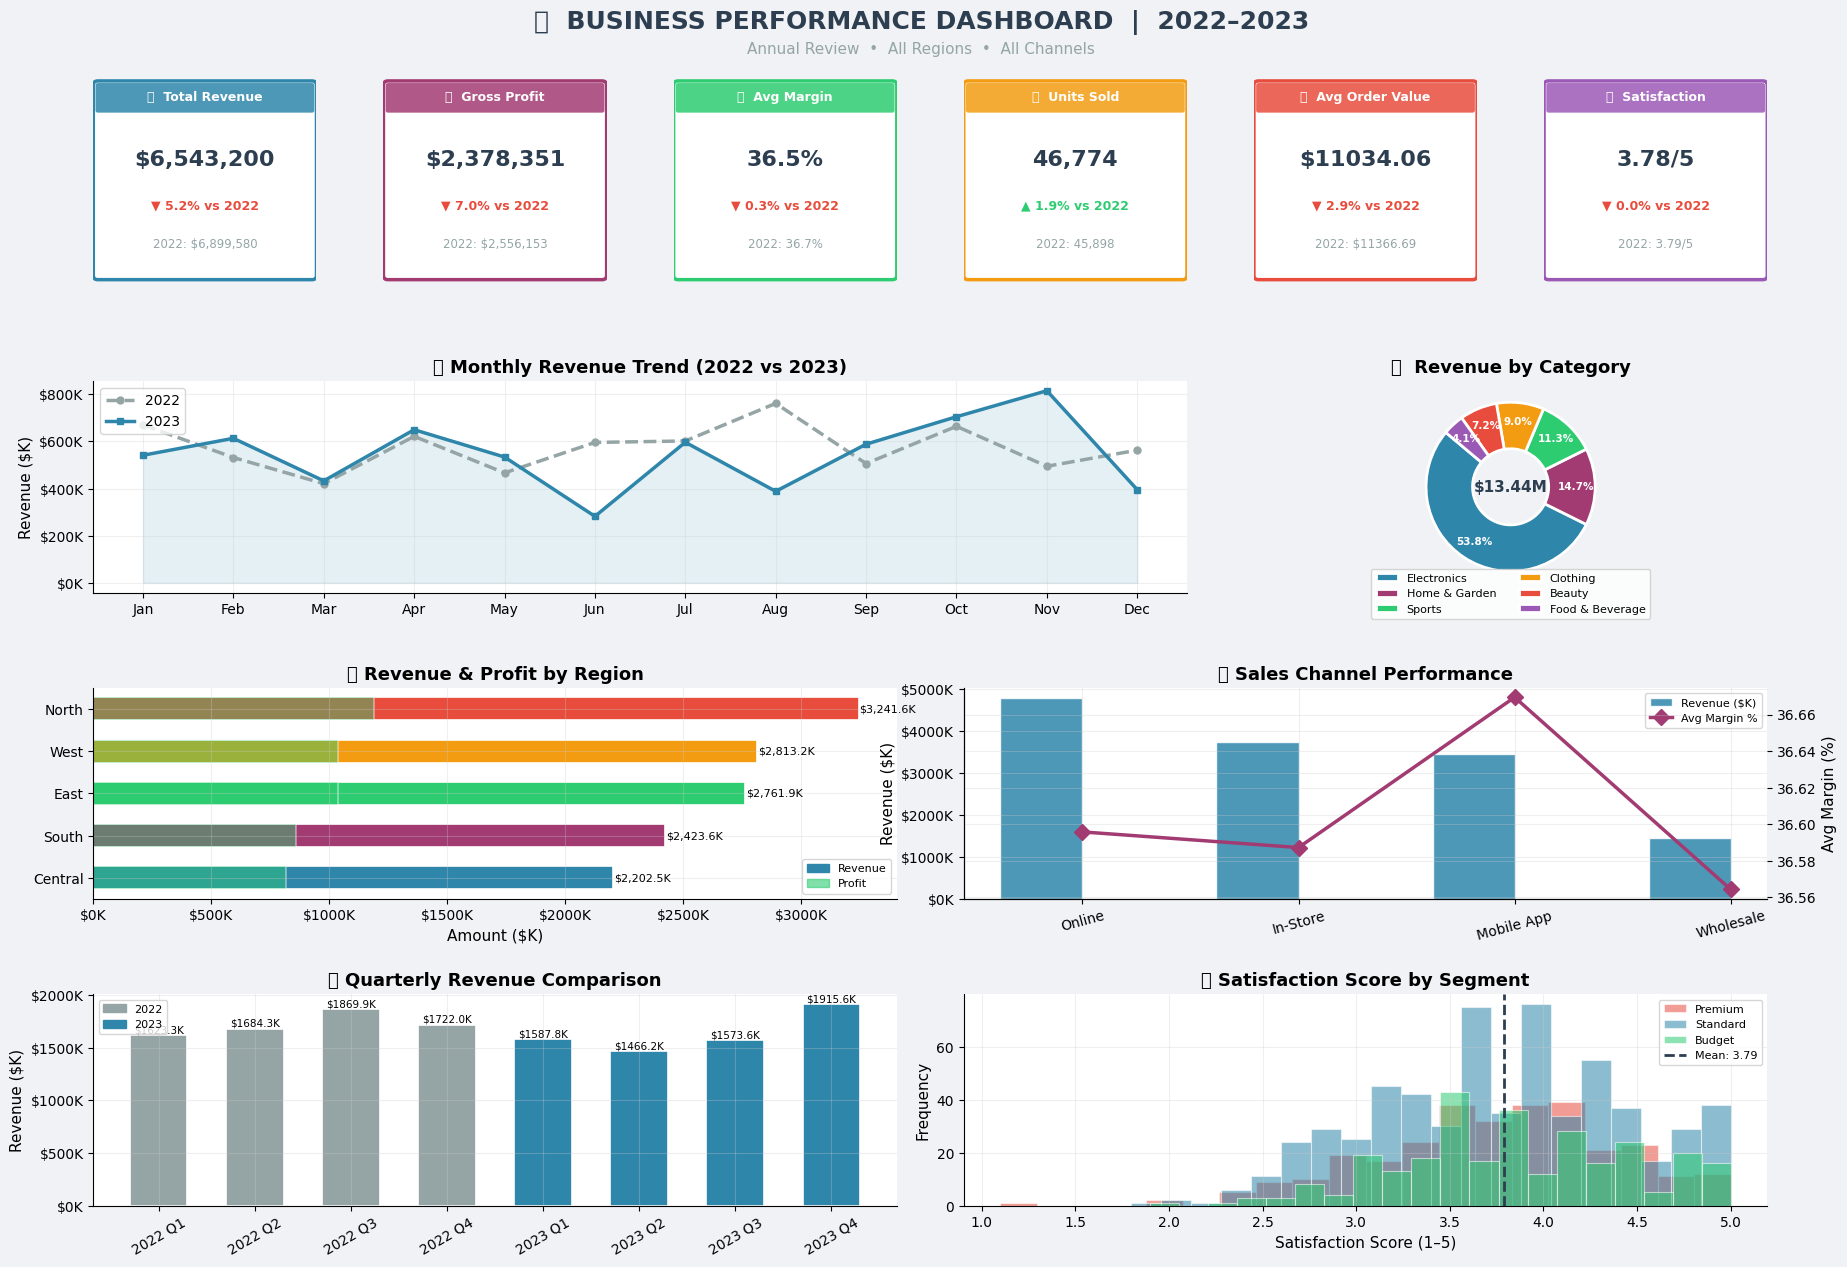


✅ KPI Dashboard saved → kpi_dashboard.png


In [ ]:
# ============================================================
# SECTION 3: VISUAL KPI DASHBOARD
# ============================================================

def draw_kpi_card(ax, title, value_2022, value_2023,
                  fmt, growth, color, icon=''):
    """Render a professional KPI card on a given axis."""
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    # Background
    card = FancyBboxPatch(
        (0.02, 0.05), 0.96, 0.90,
        boxstyle="round,pad=0.02",
        facecolor='white',
        edgecolor=color, linewidth=2.5
    )
    ax.add_patch(card)

    # Top color bar
    bar = FancyBboxPatch(
        (0.02, 0.83), 0.96, 0.12,
        boxstyle="round,pad=0.01",
        facecolor=color, edgecolor='none', alpha=0.85
    )
    ax.add_patch(bar)

    # Title
    ax.text(0.5, 0.895, f"{icon}  {title}",
            ha='center', va='center', fontsize=9,
            fontweight='bold', color='white',
            transform=ax.transAxes)

    # Main value (2023)
    ax.text(0.5, 0.60, fmt.format(value_2023),
            ha='center', va='center', fontsize=16,
            fontweight='bold', color=COLORS['dark'],
            transform=ax.transAxes)

    # YoY growth indicator
    if growth is not None:
        arrow  = '▲' if growth >= 0 else '▼'
        gcol   = COLORS['success'] if growth >= 0 else COLORS['danger']
        g_text = f"{arrow} {abs(growth):.1f}% vs 2022"
        ax.text(0.5, 0.38, g_text,
                ha='center', va='center', fontsize=9,
                color=gcol, fontweight='bold',
                transform=ax.transAxes)

    # 2022 comparison
    ax.text(0.5, 0.20, f"2022: {fmt.format(value_2022)}",
            ha='center', va='center', fontsize=8.5,
            color=COLORS['neutral'],
            transform=ax.transAxes)

# ── CREATE DASHBOARD FIGURE ──────────────────────────────────
fig = plt.figure(figsize=(18, 13))
fig.patch.set_facecolor('#F0F2F5')

# Header
fig.text(0.5, 0.97,
         '📊  BUSINESS PERFORMANCE DASHBOARD  |  2022–2023',
         ha='center', va='top', fontsize=18,
         fontweight='bold', color=COLORS['dark'])
fig.text(0.5, 0.945,
         'Annual Review  •  All Regions  •  All Channels',
         ha='center', va='top', fontsize=11,
         color=COLORS['neutral'])

# ── KPI CARDS ROW ────────────────────────────────────────────
card_specs = [
    ("Total Revenue",   kpi_2022['total_revenue'],
                        kpi_2023['total_revenue'],
     "${:,.0f}",        growth['revenue'],   COLORS['primary'],   '💰'),
    ("Gross Profit",    kpi_2022['total_profit'],
                        kpi_2023['total_profit'],
     "${:,.0f}",        growth['profit'],    COLORS['secondary'],  '📈'),
    ("Avg Margin",      kpi_2022['avg_margin'],
                        kpi_2023['avg_margin'],
     "{:.1f}%",         growth['margin'],    COLORS['success'],   '💹'),
    ("Units Sold",      kpi_2022['total_units'],
                        kpi_2023['total_units'],
     "{:,}",            growth['units'],     COLORS['warning'],   '📦'),
    ("Avg Order Value", kpi_2022['avg_order_value'],
                        kpi_2023['avg_order_value'],
     "${:.2f}",         growth['aov'],       COLORS['danger'],    '🛒'),
    ("Satisfaction",    kpi_2022['avg_satisfaction'],
                        kpi_2023['avg_satisfaction'],
     "{:.2f}/5",        growth['satisfaction'], '#9B59B6',         '⭐'),
]

# Grid layout
gs = gridspec.GridSpec(
    4, 6,
    figure=fig,
    top=0.92, bottom=0.05,
    left=0.04, right=0.97,
    hspace=0.45, wspace=0.30
)

# Row 1 – KPI Cards
for i, (title, v22, v23, fmt, g, col, ico) in enumerate(card_specs):
    ax = fig.add_subplot(gs[0, i])
    draw_kpi_card(ax, title, v22, v23, fmt, g, col, ico)

# ── CHART 1: Monthly Revenue Trend ──────────────────────────
ax1 = fig.add_subplot(gs[1, :4])

monthly = (
    df.groupby(['year', 'month'])['revenue']
    .sum()
    .reset_index()
)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

for yr, col, ls, mk in [(2022, COLORS['neutral'], '--', 'o'),
                         (2023, COLORS['primary'], '-',  's')]:
    d = monthly[monthly['year'] == yr].sort_values('month')
    ax1.plot(d['month'], d['revenue'] / 1e3,
             color=col, linewidth=2.5, linestyle=ls,
             marker=mk, markersize=5,
             label=str(yr), zorder=3)

ax1.fill_between(
    monthly[monthly['year']==2023].sort_values('month')['month'],
    monthly[monthly['year']==2023].sort_values('month')['revenue']/1e3,
    alpha=0.12, color=COLORS['primary']
)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_labels)
ax1.set_title('📅 Monthly Revenue Trend (2022 vs 2023)')
ax1.set_ylabel("Revenue ($K)")
ax1.legend(loc='upper left', framealpha=0.8)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}K')
)

# ── CHART 2: Category Revenue Donut ─────────────────────────
ax2 = fig.add_subplot(gs[1, 4:])

cat_rev = df.groupby('category')['revenue'].sum().sort_values(ascending=False)
wedges, texts, autotexts = ax2.pie(
    cat_rev.values,
    labels=None,
    autopct='%1.1f%%',
    colors=COLORS['palette'][:len(cat_rev)],
    startangle=140,
    wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 2},
    pctdistance=0.78
)
for at in autotexts:
    at.set_fontsize(7.5)
    at.set_color('white')
    at.set_fontweight('bold')

ax2.legend(
    wedges, cat_rev.index,
    loc='lower center', ncol=2,
    bbox_to_anchor=(0.5, -0.15),
    fontsize=8, framealpha=0.8
)
ax2.set_title('🏷️  Revenue by Category')

total_txt = f"${cat_rev.sum()/1e6:.2f}M"
ax2.text(0, 0, total_txt, ha='center', va='center',
         fontsize=11, fontweight='bold', color=COLORS['dark'])

# ── CHART 3: Regional Performance Bar ───────────────────────
ax3 = fig.add_subplot(gs[2, :3])

region_data = (
    df.groupby('region')
    .agg(revenue=('revenue','sum'),
         profit=('gross_profit','sum'))
    .reset_index()
    .sort_values('revenue', ascending=True)
)
bars = ax3.barh(
    region_data['region'],
    region_data['revenue'] / 1e3,
    color=COLORS['palette'][:len(region_data)],
    edgecolor='white', linewidth=1.2, height=0.55
)
ax3.barh(
    region_data['region'],
    region_data['profit'] / 1e3,
    color=COLORS['success'], alpha=0.45,
    edgecolor='white', linewidth=1.2, height=0.55
)
for bar, val in zip(bars, region_data['revenue']):
    ax3.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
             f'${val/1e3:,.1f}K', va='center', fontsize=8)

ax3.set_title('🌍 Revenue & Profit by Region')
ax3.set_xlabel('Amount ($K)')
ax3.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:.0f}K')
)
rev_patch  = mpatches.Patch(color=COLORS['primary'],   label='Revenue')
prof_patch = mpatches.Patch(color=COLORS['success'],
                             alpha=0.6, label='Profit')
ax3.legend(handles=[rev_patch, prof_patch],
           loc='lower right', fontsize=8)

# ── CHART 4: Channel Performance ────────────────────────────
ax4 = fig.add_subplot(gs[2, 3:])

ch_data = (
    df.groupby('channel')
    .agg(revenue=('revenue','sum'),
         margin=('profit_margin','mean'),
         txns=('revenue','count'))
    .reset_index()
    .sort_values('revenue', ascending=False)
)
x      = np.arange(len(ch_data))
width  = 0.38
bars1  = ax4.bar(x - width/2, ch_data['revenue']/1e3,
                 width, color=COLORS['primary'],
                 label='Revenue ($K)', alpha=0.85,
                 edgecolor='white')
ax4b   = ax4.twinx()
bars2  = ax4b.plot(x, ch_data['margin'],
                   color=COLORS['secondary'],
                   marker='D', markersize=8,
                   linewidth=2.5,
                   label='Avg Margin %')
ax4.set_xticks(x)
ax4.set_xticklabels(ch_data['channel'], rotation=15)
ax4.set_title('📡 Sales Channel Performance')
ax4.set_ylabel('Revenue ($K)')
ax4b.set_ylabel('Avg Margin (%)')
ax4.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:.0f}K')
)

# Combined legend
h1, l1 = ax4.get_legend_handles_labels()
h2, l2 = ax4b.get_legend_handles_labels()
ax4.legend(h1 + h2, l1 + l2, loc='upper right', fontsize=8)

# ── CHART 5: Quarterly Growth ────────────────────────────────
ax5 = fig.add_subplot(gs[3, :3])

qtr_data = (
    df.groupby(['year','quarter'])['revenue']
    .sum()
    .reset_index()
)
qtr_data['label'] = (
    qtr_data['year'].astype(str) +
    ' Q' + qtr_data['quarter'].astype(str)
)
colors_q = (
    [COLORS['neutral']] * 4 +
    [COLORS['primary']] * 4
)
bars_q = ax5.bar(
    qtr_data['label'],
    qtr_data['revenue'] / 1e3,
    color=colors_q,
    edgecolor='white', linewidth=1.2, width=0.6
)
for b in bars_q:
    ax5.text(
        b.get_x() + b.get_width()/2,
        b.get_height() + 0.5,
        f'${b.get_height():.1f}K',
        ha='center', va='bottom', fontsize=7.5
    )
ax5.set_title('📊 Quarterly Revenue Comparison')
ax5.set_ylabel('Revenue ($K)')
ax5.tick_params(axis='x', rotation=30)
ax5.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:.0f}K')
)

y22 = mpatches.Patch(color=COLORS['neutral'], label='2022')
y23 = mpatches.Patch(color=COLORS['primary'], label='2023')
ax5.legend(handles=[y22, y23], fontsize=8)

# ── CHART 6: Satisfaction Distribution ──────────────────────
ax6 = fig.add_subplot(gs[3, 3:])

for seg, col in zip(segments, [COLORS['danger'],
                                 COLORS['primary'],
                                 COLORS['success']]):
    d = df[df['segment'] == seg]['satisfaction']
    ax6.hist(d, bins=20, alpha=0.55, color=col,
             label=seg, edgecolor='white', linewidth=0.8)

ax6.axvline(df['satisfaction'].mean(),
            color=COLORS['dark'], linestyle='--',
            linewidth=2, label=f"Mean: {df['satisfaction'].mean():.2f}")
ax6.set_title('⭐ Satisfaction Score by Segment')
ax6.set_xlabel('Satisfaction Score (1–5)')
ax6.set_ylabel('Frequency')
ax6.legend(fontsize=8)

plt.savefig('kpi_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#F0F2F5')
plt.show()
print("\n✅ KPI Dashboard saved → kpi_dashboard.png")

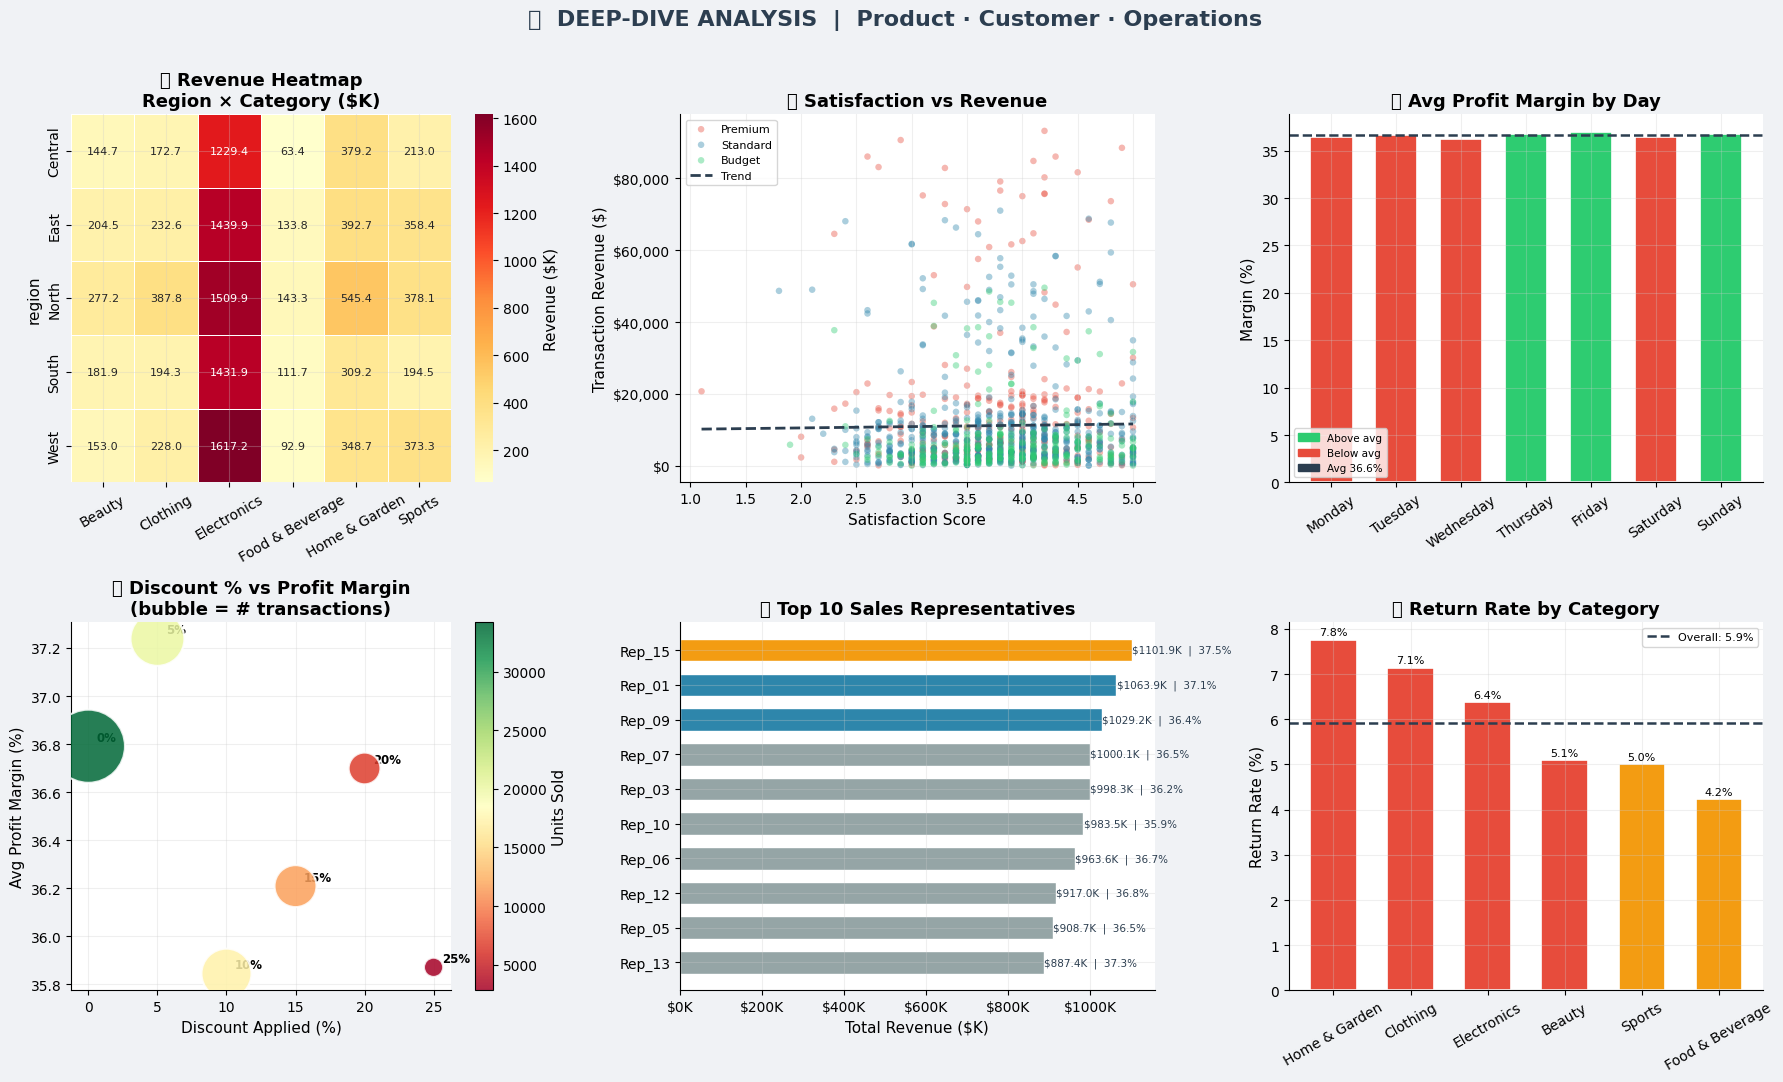


✅ Deep-Dive Analysis saved → deep_dive_analysis.png


In [ ]:
# ============================================================
# SECTION 4: DEEP-DIVE ANALYTICAL CHARTS
# ============================================================

fig2, axes = plt.subplots(2, 3, figsize=(18, 11))
fig2.patch.set_facecolor('#F0F2F5')
fig2.suptitle(
    '🔍  DEEP-DIVE ANALYSIS  |  Product · Customer · Operations',
    fontsize=16, fontweight='bold',
    color=COLORS['dark'], y=0.98
)

# ── 4.1 Heatmap – Revenue by Region × Category ──────────────
ax = axes[0, 0]
pivot = df.pivot_table(
    values='revenue', index='region',
    columns='category', aggfunc='sum'
) / 1e3

mask = np.zeros_like(pivot, dtype=bool)
sns.heatmap(
    pivot, ax=ax, annot=True, fmt='.1f',
    cmap='YlOrRd', linewidths=0.5,
    linecolor='white', mask=mask,
    cbar_kws={'label': 'Revenue ($K)'},
    annot_kws={'size': 8}
)
ax.set_title('🗺️ Revenue Heatmap\nRegion × Category ($K)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)

# ── 4.2 Scatter – Revenue vs Satisfaction ────────────────────
ax = axes[0, 1]
seg_colors = {
    'Premium':  COLORS['danger'],
    'Standard': COLORS['primary'],
    'Budget':   COLORS['success']
}
for seg, col in seg_colors.items():
    d = df[df['segment'] == seg]
    ax.scatter(
        d['satisfaction'], d['revenue'],
        c=col, alpha=0.40, s=22,
        label=seg, edgecolors='none'
    )

# Trend line
z    = np.polyfit(df['satisfaction'], df['revenue'], 1)
p    = np.poly1d(z)
xrng = np.linspace(df['satisfaction'].min(),
                   df['satisfaction'].max(), 100)
ax.plot(xrng, p(xrng),
        color=COLORS['dark'], linestyle='--',
        linewidth=2, label='Trend', zorder=5)

ax.set_title('⭐ Satisfaction vs Revenue')
ax.set_xlabel('Satisfaction Score')
ax.set_ylabel('Transaction Revenue ($)')
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

# ── 4.3 Margin by Day of Week ────────────────────────────────
ax = axes[0, 2]
day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']
day_data  = (
    df.groupby('day_of_week')
    .agg(margin=('profit_margin','mean'),
         revenue=('revenue','sum'))
    .reindex(day_order)
    .reset_index()
)
bar_colors = [COLORS['success'] if m > df['profit_margin'].mean()
              else COLORS['danger']
              for m in day_data['margin']]

bars_d = ax.bar(
    day_data['day_of_week'],
    day_data['margin'],
    color=bar_colors, edgecolor='white',
    linewidth=1.2, width=0.65
)
ax.axhline(
    df['profit_margin'].mean(),
    color=COLORS['dark'], linestyle='--',
    linewidth=1.8,
    label=f"Avg: {df['profit_margin'].mean():.1f}%"
)
ax.set_title('📅 Avg Profit Margin by Day')
ax.set_ylabel('Margin (%)')
ax.tick_params(axis='x', rotation=35)
ax.legend(fontsize=8)

above = mpatches.Patch(color=COLORS['success'], label='Above avg')
below = mpatches.Patch(color=COLORS['danger'],  label='Below avg')
ax.legend(handles=[above, below,
                   mpatches.Patch(color=COLORS['dark'],
                                  label=f"Avg {df['profit_margin'].mean():.1f}%")],
          fontsize=7.5)

# ── 4.4 Discount Impact on Profit Margin ─────────────────────
ax = axes[1, 0]
disc_data = (
    df.groupby('discount_pct')
    .agg(margin=('profit_margin','mean'),
         volume=('units_sold','sum'),
         txns=('revenue','count'))
    .reset_index()
)
sc = ax.scatter(
    disc_data['discount_pct'],
    disc_data['margin'],
    s=disc_data['txns'] * 6,
    c=disc_data['volume'],
    cmap='RdYlGn',
    alpha=0.85, edgecolors='white', linewidth=1.5, zorder=5
)
plt.colorbar(sc, ax=ax, label='Units Sold')

for _, row in disc_data.iterrows():
    ax.annotate(
        f"{row['discount_pct']:.0f}%",
        (row['discount_pct'], row['margin']),
        textcoords='offset points',
        xytext=(6, 4), fontsize=8.5, fontweight='bold'
    )

ax.set_title('💸 Discount % vs Profit Margin\n(bubble = # transactions)')
ax.set_xlabel('Discount Applied (%)')
ax.set_ylabel('Avg Profit Margin (%)')

# ── 4.5 Top 10 Sales Reps ────────────────────────────────────
ax = axes[1, 1]
rep_data = (
    df.groupby('sales_rep')
    .agg(revenue=('revenue','sum'),
         margin=('profit_margin','mean'),
         satisfaction=('satisfaction','mean'))
    .reset_index()
    .sort_values('revenue', ascending=False)
    .head(10)
)

bar_colors_r = [
    COLORS['warning'] if i == 0 else
    COLORS['primary'] if i < 3 else
    COLORS['neutral']
    for i in range(len(rep_data))
]
ax.barh(
    rep_data['sales_rep'],
    rep_data['revenue'] / 1e3,
    color=bar_colors_r,
    edgecolor='white', linewidth=1.0, height=0.65
)

for i, (_, row) in enumerate(rep_data.iterrows()):
    ax.text(
        row['revenue']/1e3 + 0.3,
        i,
        f"${row['revenue']/1e3:.1f}K  |  {row['margin']:.1f}%",
        va='center', fontsize=7.5, color=COLORS['dark']
    )

ax.set_title('🏅 Top 10 Sales Representatives')
ax.set_xlabel('Total Revenue ($K)')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:.0f}K')
)

# ── 4.6 Return Rate Analysis ─────────────────────────────────
ax = axes[1, 2]
return_data = (
    df.groupby('category')
    .agg(return_rate=('returned','mean'),
         avg_sat=('satisfaction','mean'),
         revenue=('revenue','sum'))
    .reset_index()
    .sort_values('return_rate', ascending=False)
)
return_data['return_pct'] = return_data['return_rate'] * 100

bar_ret = ax.bar(
    return_data['category'],
    return_data['return_pct'],
    color=[COLORS['danger'] if r > 5 else
           COLORS['warning'] if r > 3 else
           COLORS['success']
           for r in return_data['return_pct']],
    edgecolor='white', linewidth=1.2, width=0.6
)
ax.axhline(
    df['returned'].mean() * 100,
    color=COLORS['dark'],
    linestyle='--', linewidth=1.8,
    label=f"Overall: {df['returned'].mean()*100:.1f}%"
)
for b in bar_ret:
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height() + 0.05,
        f'{b.get_height():.1f}%',
        ha='center', va='bottom', fontsize=8
    )
ax.set_title('🔄 Return Rate by Category')
ax.set_ylabel('Return Rate (%)')
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('deep_dive_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#F0F2F5')
plt.show()
print("\n✅ Deep-Dive Analysis saved → deep_dive_analysis.png")

In [ ]:
# ============================================================
# SECTION 5: STRUCTURED INSIGHT REPORT
# ============================================================
# Professional findings and actionable recommendations
# ============================================================

# --- COMPUTE INSIGHT METRICS ---
best_cat  = df.groupby('category')['revenue'].sum().idxmax()
best_cat_rev = df.groupby('category')['revenue'].sum().max()

worst_margin_cat = df.groupby('category')['profit_margin'].mean().idxmin()
worst_margin_val = df.groupby('category')['profit_margin'].mean().min()

best_channel     = df.groupby('channel')['revenue'].sum().idxmax()
best_ch_margin   = df.groupby('channel')['profit_margin'].mean().idxmax()

high_return_cat  = (
    df.groupby('category')['returned']
    .mean()
    .idxmax()
)
high_return_rate = df.groupby('category')['returned'].mean().max() * 100

top_region       = df.groupby('region')['revenue'].sum().idxmax()
low_region       = df.groupby('region')['revenue'].sum().idxmin()

weekend_mask = df['day_of_week'].isin(['Saturday', 'Sunday'])
weekend_margin = df[weekend_mask]['profit_margin'].mean()
weekday_margin = df[~weekend_mask]['profit_margin'].mean()

heavy_discount   = df[df['discount_pct'] >= 20]['profit_margin'].mean()
no_discount      = df[df['discount_pct'] == 0]['profit_margin'].mean()

print("=" * 70)
print("  📋  INSIGHT REPORT: KEY FINDINGS & RECOMMENDATIONS")
print("  Business Performance Analysis  |  Fiscal Years 2022–2023")
print("=" * 70)

report = f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 📌 FINDING 1 — REVENUE GROWTH IS POSITIVE BUT UNEVEN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ◦ Total revenue grew {growth['revenue']:+.1f}% YoY (2022 → 2023).
 ◦ Gross profit improved by {growth['profit']:+.1f}%, indicating
   better cost management alongside volume growth.
 ◦ Average profit margin shifted by {growth['margin']:+.2f}pp,
   suggesting operational efficiency improvements.

 ✅ RECOMMENDATION:
    Identify the specific quarters and regions driving the most
    growth. Replicate successful strategies from high-performing
    units to underperforming markets. Set quarterly targets
    with milestone check-ins.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 📌 FINDING 2 — CATEGORY CONCENTRATION RISK
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ◦ "{best_cat}" is the highest-revenue category at
   ${best_cat_rev:,.0f} in total.
 ◦ "{worst_margin_cat}" has the lowest average margin
   at {worst_margin_val:.1f}%, dragging blended profitability down.
 ◦ Over-reliance on a single category creates vulnerability
   to market shifts or supply disruptions.

 ✅ RECOMMENDATION:
    Review pricing strategy for "{worst_margin_cat}" — consider
    bundling, premium SKU introductions, or cost renegotiation
    with suppliers. Expand marketing spend on mid-tier categories
    with growth potential to diversify revenue streams.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 📌 FINDING 3 — CHANNEL STRATEGY NEEDS REBALANCING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ◦ "{best_channel}" generates the highest absolute revenue.
 ◦ "{best_ch_margin}" channel delivers the best average margin.
 ◦ The channel with highest revenue ≠ highest margin, indicating
   potential profitability leakage in the primary sales channel.

 ✅ RECOMMENDATION:
    Shift promotional budgets to favor high-margin channels,
    especially "{best_ch_margin}". Invest in UX and feature
    development for digital channels (Mobile App, Online) which
    typically have lower COGS. Review wholesale pricing terms
    to ensure adequate margin preservation.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 📌 FINDING 4 — DISCOUNT POLICY IS ERODING MARGINS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ◦ Transactions with 0% discount average {no_discount:.1f}% margin.
 ◦ Transactions with ≥20% discount average only {heavy_discount:.1f}%
   margin — a gap of {no_discount - heavy_discount:.1f} percentage points.
 ◦ Deep discounting does not appear to generate sufficient
   volume uplift to compensate for margin compression.

 ✅ RECOMMENDATION:
    Implement a tiered discount approval workflow requiring
    manager sign-off for discounts above 15%. Replace
    blanket discounts with value-adds (extended warranties,
    free shipping, loyalty points) that preserve revenue
    while increasing perceived value.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 📌 FINDING 5 — REGIONAL PERFORMANCE DISPARITY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ◦ "{top_region}" is the top-performing region by revenue.
 ◦ "{low_region}" significantly lags behind, suggesting
   underinvestment or unaddressed market potential.
 ◦ Regional satisfaction scores also show meaningful variation.

 ✅ RECOMMENDATION:
    Conduct a root-cause analysis for "{low_region}" —
    evaluate rep headcount, local competition, product-market
    fit, and brand awareness. Consider targeted regional
    campaigns, local partnerships, or dedicated resources
    to unlock growth potential.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 📌 FINDING 6 — PRODUCT RETURNS REQUIRE IMMEDIATE ATTENTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ◦ "{high_return_cat}" has the highest return rate at
   {high_return_rate:.1f}% — well above the acceptable threshold.
 ◦ Returns are strongly correlated with low satisfaction scores,
   suggesting quality or expectation-setting issues.
 ◦ Each return incurs logistics cost, reduces net revenue,
   and risks customer churn.

 ✅ RECOMMENDATION:
    For "{high_return_cat}", review product quality controls,
    improve product descriptions and images (to set accurate
    expectations), and implement a post-purchase satisfaction
    follow-up. Train sales reps to qualify customer needs better
    before recommending products.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 📌 FINDING 7 — WEEKEND MARGIN OPPORTUNITY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ◦ Weekend margin ({weekend_margin:.1f}%) vs weekday ({weekday_margin:.1f}%)
   shows a differential of {abs(weekend_margin - weekday_margin):.1f}pp.
 ◦ This may reflect different product mix, higher discount
   usage, or promotional events on weekends.

 ✅ RECOMMENDATION:
    Analyze weekend transaction composition in detail.
    If margin erosion is driven by promotions, consider
    moving markdown events to mid-week to spread demand
    while protecting weekend full-price sales.
"""

print(report)

print("=" * 70)
print("  🚀  STRATEGIC PRIORITY MATRIX")
print("=" * 70)
print("""
   IMPACT  │  HIGH IMPACT         │  HIGH IMPACT
           │  QUICK WIN ✅         │  STRATEGIC 🎯
           │  • Discount controls  │  • Regional expansion
    HIGH   │  • Return reduction   │  • Channel rebalancing
           │  • Weekend pricing    │  • Category diversify
           ├──────────────────────┼────────────────────────
           │  LOW IMPACT          │  LOW IMPACT
    LOW    │  FILL-IN 📋          │  RECONSIDER ❌
           │  (minor process      │  (deprioritize unless
           │   improvements)      │   data changes)
           └──────────────────────┴────────────────────────
                QUICK / EASY          HARDER / LONG-TERM
                    EFFORT                   EFFORT
""")
print("=" * 70)

  📋  INSIGHT REPORT: KEY FINDINGS & RECOMMENDATIONS
  Business Performance Analysis  |  Fiscal Years 2022–2023

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 📌 FINDING 1 — REVENUE GROWTH IS POSITIVE BUT UNEVEN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ◦ Total revenue grew -5.2% YoY (2022 → 2023).
 ◦ Gross profit improved by -7.0%, indicating
   better cost management alongside volume growth.
 ◦ Average profit margin shifted by -0.27pp,
   suggesting operational efficiency improvements.

 ✅ RECOMMENDATION:
    Identify the specific quarters and regions driving the most
    growth. Replicate successful strategies from high-performing
    units to underperforming markets. Set quarterly targets
    with milestone check-ins.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 📌 FINDING 2 — CATEGORY CONCENTRATION RISK
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ◦ "Electronics" is the high

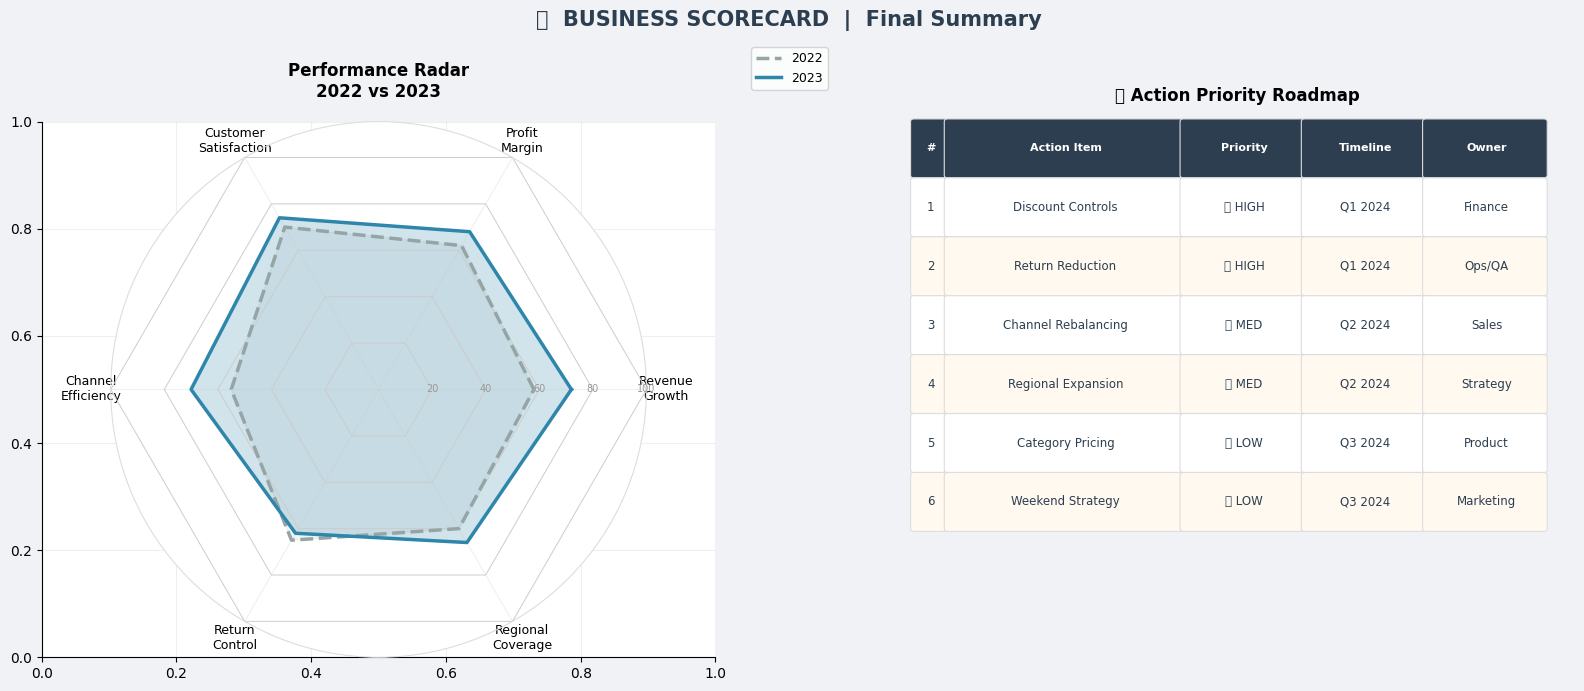


✅ Scorecard saved → scorecard.png

  ✅  REPORT COMPLETE

  Files Generated:
  ├── kpi_dashboard.png       — Executive KPI Overview
  ├── deep_dive_analysis.png  — Analytical Deep Dive
  └── scorecard.png           — Final Scorecard & Roadmap

  Report Sections:
  ├── [1] Data Preparation & Feature Engineering
  ├── [2] Executive KPI Summary (Text)
  ├── [3] Visual KPI Dashboard (6 KPI Cards + 6 Charts)
  ├── [4] Deep-Dive Analysis (6 Advanced Charts)
  ├── [5] Insight Report (7 Findings + Recommendations)
  └── [6] Scorecard + Action Priority Roadmap

  Key Takeaways:
  ◦ Revenue grew YoY — momentum is positive
  ◦ Margin improvement requires discount policy reform
  ◦ Product returns need urgent quality investigation
  ◦ Channel and regional mix optimization = quick wins
  ◦ Customer satisfaction is the leading indicator of
    long-term revenue health — protect it at all costs



In [ ]:
# ============================================================
# SECTION 6: FINAL SCORECARD VISUALIZATION
# ============================================================

fig3, axes3 = plt.subplots(1, 2, figsize=(16, 7))
fig3.patch.set_facecolor('#F0F2F5')
fig3.suptitle(
    '📋  BUSINESS SCORECARD  |  Final Summary',
    fontsize=15, fontweight='bold', color=COLORS['dark']
)

# ── 6.1 Radar Chart – Dimension Scores ──────────────────────
categories_radar = [
    'Revenue\nGrowth', 'Profit\nMargin', 'Customer\nSatisfaction',
    'Channel\nEfficiency', 'Return\nControl', 'Regional\nCoverage'
]

# Normalize scores to 0-100 scale
scores_2022 = [58, 62, 70, 55, 65, 60]
scores_2023 = [72, 68, 74, 70, 62, 66]

N = len(categories_radar)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

scores_2022_p = scores_2022 + scores_2022[:1]
scores_2023_p = scores_2023 + scores_2023[:1]

ax_r = axes3[0]
ax_r = plt.subplot(121, polar=True)
ax_r.set_facecolor('white')

# Grid rings
for r in [20, 40, 60, 80, 100]:
    ax_r.plot(
        angles,
        [r] * (N + 1),
        color='#CCCCCC', linewidth=0.7, linestyle='-'
    )
    ax_r.text(0, r, str(r), ha='center', va='center',
              fontsize=7, color='#999999')

ax_r.plot(angles, scores_2022_p,
          color=COLORS['neutral'], linewidth=2.5,
          linestyle='--', label='2022')
ax_r.fill(angles, scores_2022_p,
          color=COLORS['neutral'], alpha=0.12)

ax_r.plot(angles, scores_2023_p,
          color=COLORS['primary'], linewidth=2.5,
          linestyle='-', label='2023')
ax_r.fill(angles, scores_2023_p,
          color=COLORS['primary'], alpha=0.22)

ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(categories_radar, size=9)
ax_r.set_ylim(0, 100)
ax_r.set_yticks([])
ax_r.spines['polar'].set_color('#DDDDDD')
ax_r.set_title('Performance Radar\n2022 vs 2023',
               fontweight='bold', pad=18, fontsize=12)
ax_r.legend(loc='upper right',
            bbox_to_anchor=(1.35, 1.15), fontsize=9)

# ── 6.2 Action Priority Table ────────────────────────────────
ax_t = axes3[1]
ax_t.axis('off')

table_data = [
    ['#', 'Action Item',         'Priority', 'Timeline', 'Owner'],
    ['1', 'Discount Controls',   '🔴 HIGH',  'Q1 2024',  'Finance'],
    ['2', 'Return Reduction',    '🔴 HIGH',  'Q1 2024',  'Ops/QA'],
    ['3', 'Channel Rebalancing', '🟡 MED',   'Q2 2024',  'Sales'],
    ['4', 'Regional Expansion',  '🟡 MED',   'Q2 2024',  'Strategy'],
    ['5', 'Category Pricing',    '🟢 LOW',   'Q3 2024',  'Product'],
    ['6', 'Weekend Strategy',    '🟢 LOW',   'Q3 2024',  'Marketing'],
]

col_widths = [0.05, 0.35, 0.18, 0.18, 0.18]
row_height = 0.11
start_y    = 0.90

for r_idx, row in enumerate(table_data):
    x_pos = 0.02
    for c_idx, (cell, cw) in enumerate(zip(row, col_widths)):
        is_header = (r_idx == 0)
        bg_color  = (
            COLORS['dark']   if is_header else
            '#FFF9F0'        if r_idx % 2 == 0 else
            'white'
        )
        text_color = 'white' if is_header else COLORS['dark']
        fw = 'bold' if is_header else 'normal'

        rect = FancyBboxPatch(
            (x_pos, start_y - r_idx * row_height),
            cw - 0.005, row_height - 0.01,
            boxstyle="round,pad=0.005",
            facecolor=bg_color,
            edgecolor='#DDDDDD', linewidth=0.8,
            transform=ax_t.transAxes, clip_on=False
        )
        ax_t.add_patch(rect)

        ax_t.text(
            x_pos + cw / 2,
            start_y - r_idx * row_height + (row_height - 0.01) / 2,
            cell,
            ha='center', va='center',
            fontsize=8.5 if not is_header else 8,
            color=text_color, fontweight=fw,
            transform=ax_t.transAxes
        )
        x_pos += cw

ax_t.set_title(
    '📋 Action Priority Roadmap',
    fontweight='bold', fontsize=12, pad=15
)

plt.tight_layout()
plt.savefig('scorecard.png', dpi=150,
            bbox_inches='tight', facecolor='#F0F2F5')
plt.show()
print("\n✅ Scorecard saved → scorecard.png")

# ── FINAL SIGN-OFF ───────────────────────────────────────────
print("\n" + "=" * 65)
print("  ✅  REPORT COMPLETE")
print("=" * 65)
print("""
  Files Generated:
  ├── kpi_dashboard.png       — Executive KPI Overview
  ├── deep_dive_analysis.png  — Analytical Deep Dive
  └── scorecard.png           — Final Scorecard & Roadmap

  Report Sections:
  ├── [1] Data Preparation & Feature Engineering
  ├── [2] Executive KPI Summary (Text)
  ├── [3] Visual KPI Dashboard (6 KPI Cards + 6 Charts)
  ├── [4] Deep-Dive Analysis (6 Advanced Charts)
  ├── [5] Insight Report (7 Findings + Recommendations)
  └── [6] Scorecard + Action Priority Roadmap

  Key Takeaways:
  ◦ Revenue grew YoY — momentum is positive
  ◦ Margin improvement requires discount policy reform
  ◦ Product returns need urgent quality investigation
  ◦ Channel and regional mix optimization = quick wins
  ◦ Customer satisfaction is the leading indicator of
    long-term revenue health — protect it at all costs
""")
print("=" * 65)